In [1]:
import pickle
import matplotlib.pyplot as plt
import glob
from joblib import Parallel, delayed
import numpy as np

In [2]:


dirr = 'results_1000'

#results/simualtion_res_treatment{treatment}_beta{beta}_LOO{LOO}.p

fnames = glob.glob(f'{dirr}/*')

print(len(fnames))


21051


In [3]:

PR_consensus = 'PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKPKMIGGIGGFIKVRQYDQILIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF'

PR_consensus = np.array(list(PR_consensus))



In [4]:
def parse_fname(fname):

    stem = fname.split('/')[-1]

    parser = stem.split('_')

    treatment = parser[2][9:]
    beta = float(parser[3][4:])

    LOO = parser[-1].split('.')[0]

    if LOO[0] == 'L':
        LOO = int(LOO[3:])
    else:
        LOO = None

    
    
    return treatment, beta, LOO
    

In [5]:

# Get onehot_inv_maps of all treatments to generate mutation genotypes

fname = 'PI_treatments_dict.p'
with open(fname, 'rb') as dbfile:
    PI_treatments = pickle.load(dbfile)


onehot_inv_map = dict()

for treatment in PI_treatments:

    fname = f'treatment{treatment}_PR_evol_onehot_logistic.p'
    with open(fname, 'rb') as dbfile:
        info = pickle.load(dbfile)
    
    PR_onehot_encoder = info['onehot_encoder']

    onehot_inv_map[treatment] = dict()

    bit_idx = 0 
    
    for pos, cat in enumerate(PR_onehot_encoder.categories_):
    
        for AA in cat:
            onehot_inv_map[treatment][bit_idx] = (pos, AA)
    
            bit_idx += 1
    

    

In [ ]:
# # I want mutation propensity of ALL PR sequences. The issue is that for some I cannot do onehot encoding

# all_PR_onehot_encoders = dict()
# all_PR_logistic_regression = dict()

# all_seqs = []


# for treatment in PI_treatments:
    
#     fname = f'treatment{treatment}_PR_evol_onehot_logistic.p'
#     dbfile = open(fname, 'rb')
#     info = pickle.load(dbfile)
#     dbfile.close()
    
#     all_PR_onehot_encoders[treatment] = info['onehot_encoder']
#     all_PR_logistic_regression[treatment] = info['logistic_regression']

#     all_seqs.append(PI_treatments[treatment])
    

# all_seqs = np.vstack(all_seqs)

# from tqdm import tqdm

# # I need the observed PR isolates that can be onehotencoded for all treatments!

# print(all_seqs.shape)

# valid_seqs = []

# # 1. Assign the tqdm iterator to a variable, e.g., 'pbar'
# with tqdm(all_seqs, desc="Processing sequences") as pbar:
#     for seq in pbar:
#         flag = 1
#         for treatment in all_PR_onehot_encoders:
#             try:
#                 # Your original logic
#                 onehot_seq = np.array(all_PR_onehot_encoders[treatment].transform(seq.reshape(1,-1)).todense())[0]
#             except:
#                 flag = 0
#                 break
        
#         if flag:
#             valid_seqs.append(seq)
#             # 2. Update the postfix right after appending a valid sequence.
#             # This will dynamically show the count of valid sequences found so far.
#             pbar.set_postfix({'valid_seqs': len(valid_seqs)})

# valid_seqs = np.vstack(valid_seqs)




# unique_valid_seqs = np.unique(valid_seqs, axis=0)

# print(unique_valid_seqs.shape)

# fname = 'unique_valid_seqs_for_mutation_propensity_comparison.npy'
# np.save(fname, unique_valid_seqs)




In [ ]:

fname = 'unique_valid_seqs_for_mutation_propensity_comparison.npy'
unique_valid_seqs = np.load(fname)


In [ ]:
from tqdm import tqdm

all_mutation_propensities = dict()
    
# Finally, I have to compute mutation propensity of the valid sequences!

for treatment in all_PR_onehot_encoders:

    print(f'Doing treatment {treatment}')

    all_mutation_propensities[treatment] = []
    
    fname = f'treatment{treatment}_PR_evol_onehot_logistic.p'
    dbfile = open(fname, 'rb')
    info = pickle.load(dbfile)
    dbfile.close()
    
    PR_onehot_encoder = info['onehot_encoder']
    PR_logistic_regression = info['logistic_regression']
    
    lenns = []
    
    onehot_map = dict()
    
    pos_info = dict()
    
    bit_idx = 0 
    
    non_varying_bits = []
    
    for pos, cat in enumerate(PR_onehot_encoder.categories_):
    
        lenns.append(len(cat))
    
        for AA in cat:
            onehot_map[(pos, AA)] = bit_idx
    
            if lenns[-1] == 1:
                non_varying_bits.append(bit_idx)
                
            bit_idx += 1
    
    non_varying_bits = np.array(non_varying_bits, dtype=int)
    
    n_bits = bit_idx
    
    lenns = np.array(lenns)
    
    boundaries = np.hstack([[0], np.cumsum(lenns)])

    for this_seq in tqdm(unique_valid_seqs):

        onehot_seq = np.array(PR_onehot_encoder.transform(this_seq.reshape(1,-1)).todense())[0]
    
        seq_log_probs = np.zeros((len(this_seq),))
    
        for pos in range(len(boundaries)-1):

            # IGNORE NON-VARYING POSITIONS
            if lenns[pos] == 1:
                continue
    
            this_pos_model = PR_logistic_regression[pos]
    
            start = boundaries[pos]
            end = boundaries[pos+1]
    
            xx = np.hstack([onehot_seq[:start], onehot_seq[end:]])
    
            pos_log_probs = this_pos_model.predict_log_proba(xx.reshape(1,-1))[0]
    
            this_pos_classes = list(this_pos_model.classes_)
            
            this_AA = this_seq[pos]
    
            for AA, log_prob in zip(this_pos_model.classes_, pos_log_probs):
    
                bit_idx = onehot_map[(pos, AA)]
    
                if AA == this_AA:
                    seq_log_probs[pos] = log_prob
    
        mutation_propensity = abs(np.min(seq_log_probs))

        all_mutation_propensities[treatment].append(mutation_propensity)


        
for treatment in all_mutation_propensities:

    all_mutation_propensities[treatment] = np.hstack(all_mutation_propensities[treatment])



all_cats = []
all_vals = []

for treatment in all_mutation_propensities:

    if treatment == 'None':
        continue

    nn = len(all_mutation_propensities[treatment])

    all_cats.append(nn*[treatment])
    all_vals.append(all_mutation_propensities[treatment] - all_mutation_propensities['None'])


all_cats = np.hstack(all_cats)
all_vals = np.hstack(all_vals)


import seaborn as sns

def get_sort_key(treatment_name):
    # # Special case for 'None' to ensure it's always first
    # if treatment_name == 'None':
    #     return (0, treatment_name) 
    # else:
    # 1. Splits the treatment name by ',' into a list of therapies
    therapies = treatment_name.split(',')
    # 2. Counts the number of therapies
    num_components = len(therapies)
    # 3. Returns a tuple for sorting: (count, then name)
    return (num_components, treatment_name)

# Gets the list of all unique treatments from your data
unique_treatments = list(np.unique(all_cats))

# 4. Sorts the list automatically using the logic above
ordered_labels = sorted(unique_treatments, key=get_sort_key)

# --- 4. Create the Ordered Plot ---
# --- 4. Create the Plot with Enhanced Visuals ---
# Set a style for a clean look
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure and axes objects with a larger size
fig, ax = plt.subplots(figsize=(16, 10))

# Define a bright blue color
bright_blue = "#0077FF"

# Create the box plot
sns.boxplot(
    x=all_cats,
    y=all_vals,
    order=ordered_labels,
    color=bright_blue,
    width=0.5,\
    boxprops=dict(edgecolor='black', linewidth=1.5), # Add black edge to boxes
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    showfliers=False,
    flierprops={"marker": "o", "markersize": 0, "markerfacecolor": "grey", "markeredgecolor": "black"}
)

# --- 5. Apply Larger Font Sizes and Formatting ---
# Title with large font and padding
ax.set_title('Distribution of Mutation Propensity by Treatment Complexity', fontsize=24, pad=25, weight='bold')

# Axis labels with large font and padding
ax.set_xlabel('Treatment regimen', fontsize=24, labelpad=10)
ax.set_ylabel('Change in mutation propensity\nwrt no treatment', fontsize=24, labelpad=10)

# Tick labels with large font
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.gca().axhline(y=0, ls='--', lw=2, color='red')

# Ensure the plot layout is tight to prevent labels from being cut off
plt.tight_layout()

plt.savefig(f'fig1_revision.jpg', dpi=600, bbox_inches='tight')

# Save the figure with high resolution and show it
# plt.savefig("large_font_boxplot.png", dpi=300)
plt.show()

    

In [6]:
from tqdm import tqdm

# FIGURE 2 TO SHOW non-linear relationship between beta and fitness (mutation propensity)

# Only for None LOO and show only for None treatment

all_unique_genotypes = dict()
all_unique_fitness = dict()

for fname in tqdm(fnames):

    treatment, beta, LOO = parse_fname(fname)

    if treatment != 'None':
        continue

    if LOO is not None:
        continue

    if beta not in all_unique_genotypes:
        all_unique_genotypes[beta] = []
        all_unique_fitness[beta] = []

    dbfile = open(fname, 'rb')
    data = pickle.load(dbfile)
    dbfile.close()
    
    for walk in data:
    
        walk_mutations = walk['walk_mutations']
        walk_FEM_fitness = np.array(walk['walk_FEM_fitness'])
    
        walk_seqs = []
    
        first_seq = PR_consensus.copy()
    
        this_seq = first_seq.copy()
    
        for mutate_bit_idx in walk_mutations:
            
            pos, AA = onehot_inv_map[treatment][mutate_bit_idx]
    
            this_seq[pos] = AA
    
            walk_seqs.append(this_seq.copy())
    
    
        walk_seqs = np.vstack(walk_seqs)
    
        unique_seqs, genotypes_indices = np.unique(walk_seqs, axis=0, return_index=True)

        unique_fitness = walk_FEM_fitness[genotypes_indices]

        all_unique_genotypes[beta].append(unique_seqs)
        all_unique_fitness[beta].append(unique_fitness)
    

for beta in all_unique_genotypes:

    print(beta)
    
    all_unique_genotypes[beta] = np.vstack(all_unique_genotypes[beta])
    all_unique_fitness[beta] = np.hstack(all_unique_fitness[beta])

    print(all_unique_genotypes[beta].shape, len(all_unique_fitness[beta]))

    unique_seqs, genotypes_indices = np.unique(all_unique_genotypes[beta], axis=0, return_index=True)

    all_unique_fitness[beta] = all_unique_fitness[beta][genotypes_indices]

    
    

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21051/21051 [00:57<00:00, 363.41it/s]


0.4
(608033, 99) 608033
0.5
(357666, 99) 357666
0.65
(169563, 99) 169563
0.6
(208189, 99) 208189
0.75
(123451, 99) 123451
0.7
(143621, 99) 143621
0.8
(108436, 99) 108436
0.9
(86393, 99) 86393
1.0
(69443, 99) 69443


In [38]:
def generate_consistent_plots(fitness_data: dict):
    """
    Generates two figures with a consistent design aesthetic.

    1. Main Figure: A complete plot with all beta values.
    2. Focused Figure: A zoomed-in version for beta 0.6 to 0.8 that
       perfectly matches the style of the main plot.

    Args:
        fitness_data (dict): A dictionary where keys are float values of beta
                             and values are lists of fitness scores.
    """
    if not fitness_data:
        print("Input dictionary is empty. Cannot generate plots.")
        return

    # --- 1. Prepare Data for All Plots ---
    plt.style.use('seaborn-v0_8-whitegrid')
    sorted_betas = sorted(fitness_data.keys())
    full_dataset = [fitness_data[beta] for beta in sorted_betas]
    full_medians = [np.median(data) for data in full_dataset]
    full_counts = [len(data) for data in full_dataset]

    # ====================================================================
    # --- Plot 1: Main Figure (Unchanged) ---
    # ====================================================================
    fig1, ax1 = plt.subplots(figsize=(16, 7))

    parts1 = ax1.violinplot(full_dataset, positions=sorted_betas, widths=0.03,
                            showmedians=False, showextrema=False)
    for pc in parts1['bodies']:
        pc.set_facecolor('lightgrey')
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

    ax1.plot(sorted_betas, full_medians, color='blue', marker='o', linestyle='-',
             markersize=10, label='Median mutation propensity')

    ax1_twin = ax1.twinx()
    ax1_twin.plot(sorted_betas, full_counts, color='crimson', marker='.', linestyle='--',
                  markersize=20, label='Unique genotypes')

    ax1.set_xlabel('1/mutability (β)', fontsize=28)
    ax1.set_ylabel('Mutation propensity', fontsize=28)
    ax1.set_ylim(0, 25)
    ax1.tick_params(axis='both', which='major', labelsize=18)
    ax1.invert_xaxis()
    ax1.grid(False) # No gridlines

    ax1_twin.set_ylabel('Unique genotypes', fontsize=24, color='crimson')
    ax1_twin.tick_params(axis='y', labelcolor='crimson', labelsize=18)
    ax1_twin.set_ylim(bottom=0)
    ax1_twin.grid(False)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=18)

    plt.tight_layout()
    plt.savefig('main_figure.jpg', dpi=600, bbox_inches='tight')
    plt.show()
    print("✅ Main figure saved as 'main_figure.jpg'")
    plt.close(fig1)

    # ====================================================================
    # --- Plot 2: Focused Figure (Updated for Consistency) ---
    # ====================================================================
    fig2, ax2 = plt.subplots(figsize=(10, 7))

    # Filter data for the focused plot
    focused_betas = [b for b in sorted_betas if 0.6 <= b <= 0.8]
    focused_dataset = [fitness_data[b] for b in focused_betas]
    focused_medians = [np.median(data) for data in focused_dataset] # Calculate medians for the line

    # Plot violins with the SAME style as the main plot (no internal lines)
    parts2 = ax2.violinplot(focused_dataset, positions=focused_betas, widths=0.04,
                            showmedians=False, showextrema=False)
    
    for pc in parts2['bodies']:
        pc.set_facecolor('lightgrey')
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

    # # Plot the median line with the SAME style as the main plot
    # ax2.plot(focused_betas, focused_medians, color='blue', marker='o', linestyle='-',
    #          markersize=10, label='Median mutation propensity')

    # --- Styling for Focused Figure ---
    ax2.set_title('Focused View: β from 0.8 to 0.6', fontsize=20)
    ax2.set_xlabel('1/mutability (β)', fontsize=24)
    ax2.set_ylabel('Mutation propensity', fontsize=24)
    # ax2.set_xlim(0.81, 0.59)
    ax2.invert_xaxis()
    ax2.tick_params(axis='both', which='major', labelsize=18)
    ax2.grid(False) # No gridlines to match main plot
    # ax2.legend(loc='upper left', fontsize=18) # Add legend to identify the blue line
    
    ax2.axhline(y=9, ls='--', color='black', alpha=0.6)
    ax2.axhline(y=4, ls='--', color='black', alpha=0.6)

    plt.tight_layout()
    plt.savefig('focused_figure_consistent.jpg', dpi=600, bbox_inches='tight')
    print("✅ Focused figure saved as 'focused_figure_consistent.jpg'")
    plt.show()
    

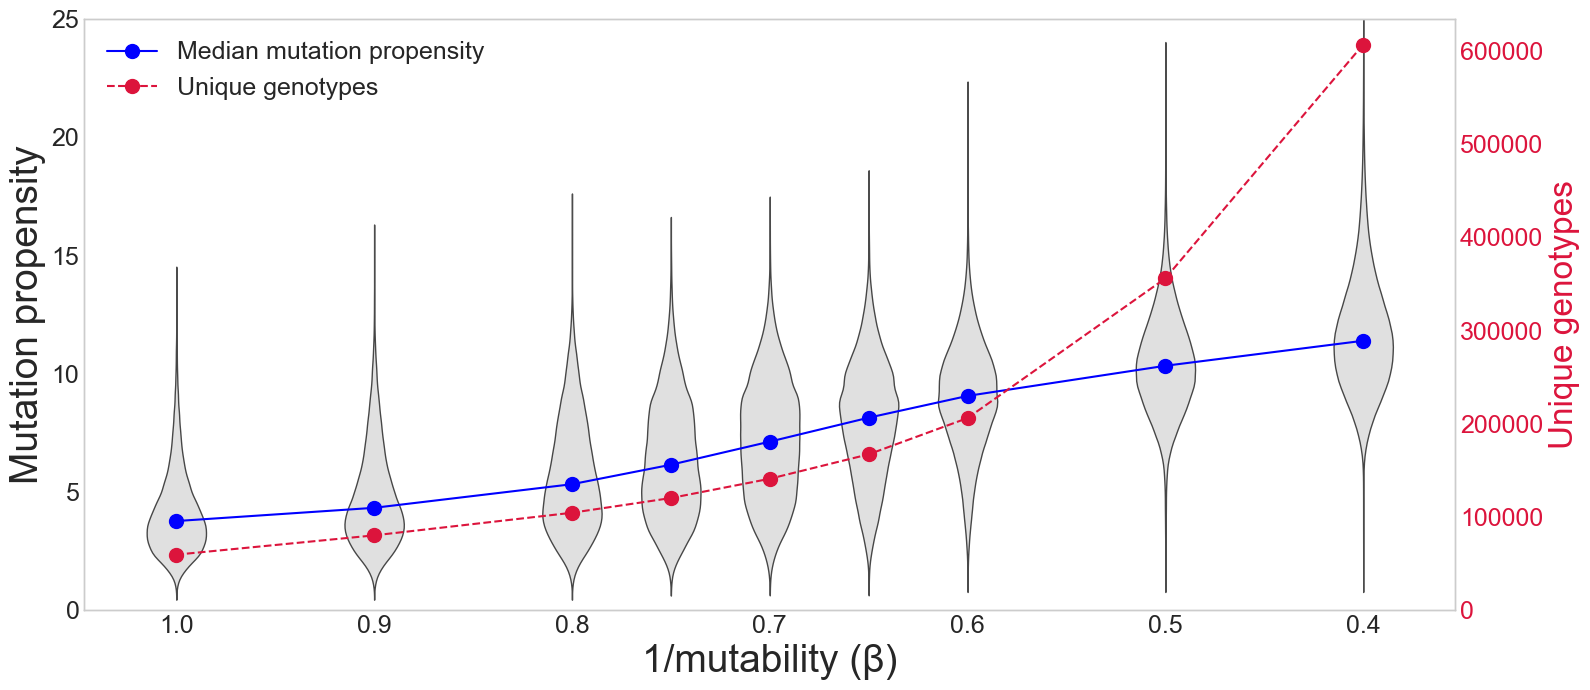

✅ Main figure saved as 'main_figure.jpg'
✅ Focused figure saved as 'focused_figure_consistent.jpg'


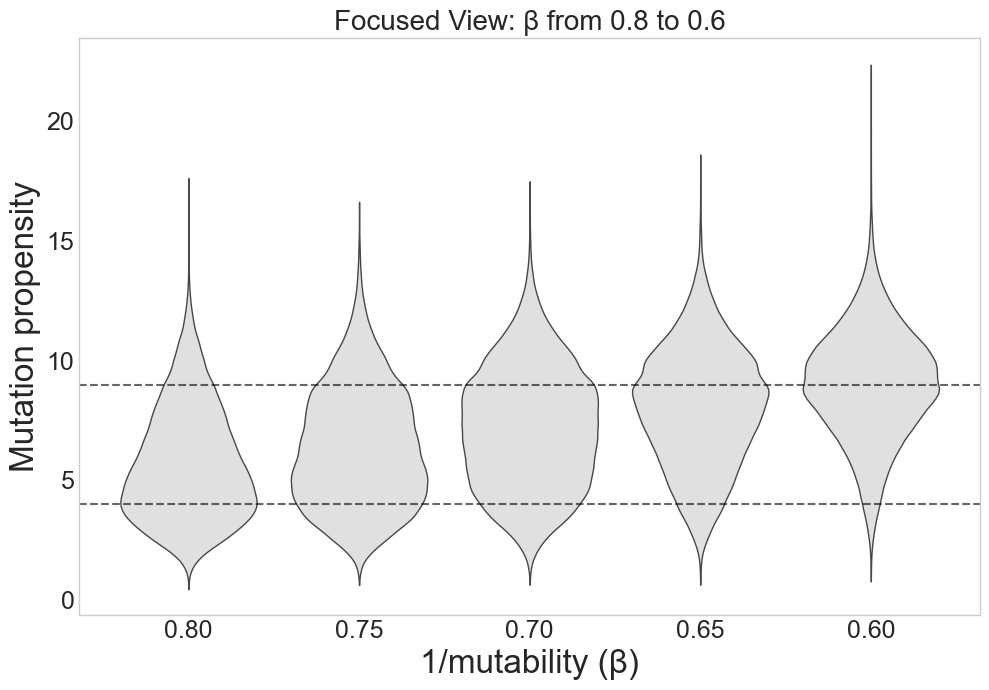

In [39]:
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter

generate_consistent_plots(all_unique_fitness)


In [ ]:
# # PLOT Figure 2 to show non-linear relationship between beta and fitness (mutation propensity)

# import seaborn as sns
# import scipy

# mean_mutation_propensity = []
# std_mutation_propensity = []
# cov_mutation_propensity = []
# betas = []

# for beta in all_unique_fitness:

#     sns.histplot(all_unique_fitness[beta], label=beta, kde=True, alpha=0.8)

#     betas.append(beta)
#     mean_mutation_propensity.append(np.mean(all_unique_fitness[beta]))
#     std_mutation_propensity.append(np.std(all_unique_fitness[beta]))
#     cov_mutation_propensity.append(scipy.stats.variation(all_unique_fitness[beta]))

# # plt.gca().axvline(x=5, ls='--', color='black')
# # plt.gca().axvline(x=10, ls='--', color='black')

# plt.xlim([0, 25])

# plt.title(f'Treatment None', fontsize=18)

# plt.xlabel(f'Mutation propensity', fontsize=16)
# plt.ylabel(f'Counts of unique genotypes', fontsize=16)

# # plt.yscale('log')

# plt.legend()

# plt.savefig(f'fig2a_revision.jpg', dpi=600, bbox_inches='tight')


# plt.tight_layout()
# plt.show()



# betas = np.array(betas)
# mean_mutation_propensity = np.array(mean_mutation_propensity)
# std_mutation_propensity = np.array(std_mutation_propensity)
# cov_mutation_propensity = np.array(cov_mutation_propensity)


In [ ]:

# idxs = np.argsort(betas)

# betas = betas[idxs]
# mean_mutation_propensity = mean_mutation_propensity[idxs]
# std_mutation_propensity = std_mutation_propensity[idxs]
# cov_mutation_propensity = cov_mutation_propensity[idxs]

# # Create figure and primary axis
# fig, ax1 = plt.subplots(figsize=(8, 6))

# # Plot mean mutation propensity on primary y-axis
# color1 = 'tab:blue'
# ax1.set_xlabel(r'1/mutability ($\beta$)', fontsize=16)
# ax1.set_ylabel('mean\nof mutation propensity', fontsize=16, color=color1)
# ax1.plot(betas, mean_mutation_propensity, color=color1, marker='o', markersize=6, label='Mean')
# ax1.tick_params(axis='y', labelcolor=color1, labelsize=16)
# ax1.tick_params(axis='x', labelsize=14)
# ax1.invert_xaxis()

# # Create secondary y-axis
# ax2 = ax1.twinx()
# color2 = 'tab:red'
# ax2.set_ylabel('std. dev.\nof mutation propensity', fontsize=16, color=color2)
# ax2.plot(betas, std_mutation_propensity, color=color2, marker='s', markersize=6, label='Std Dev')
# ax2.tick_params(axis='y', labelcolor=color2, labelsize=16)

# # # Add legend with increased font size
# # lines1, labels1 = ax1.get_legend_handles_labels()
# # lines2, labels2 = ax2.get_legend_handles_labels()
# # ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=16)

# plt.savefig(f'fig2b_revision.jpg', dpi=600, bbox_inches='tight')

# plt.tight_layout()
# plt.show()



# # plt.plot(betas, cov_mutation_propensity)
# # plt.gca().invert_xaxis()
# # plt.xlabel('beta', fontsize=16)
# # plt.ylabel('coefficient of variation\nof mutation propensity', fontsize=16)
# # plt.show()







In [ ]:

from tqdm import tqdm
# Figure 3 to show scatter plot of log(-log prog to reach drug res) and mutation propensity

# Proposal: log(-log prog to reach drug res) -> 'Drug Susceptibility'

drug_res_counts = dict()

for fname in tqdm(fnames):

    treatment, beta, LOO = parse_fname(fname)

    if LOO is not None:
        continue

    if treatment not in drug_res_counts:
        drug_res_counts[treatment] = dict()

    if beta not in drug_res_counts[treatment]:
        drug_res_counts[treatment][beta] = dict()
        drug_res_counts[treatment][beta]['unique_genotypes'] = []
        drug_res_counts[treatment][beta]['drug_res_genotypes'] = dict()
        
        
    dbfile = open(fname, 'rb')
    data = pickle.load(dbfile)
    dbfile.close()

    
    
    for walk in data:
    
        walk_mutations = walk['walk_mutations']

        walk_seqs = []
    
        first_seq = PR_consensus.copy()
    
        this_seq = first_seq.copy()
    
        for mutate_bit_idx in walk_mutations:
            
            pos, AA = onehot_inv_map[treatment][mutate_bit_idx]
    
            this_seq[pos] = AA
    
            walk_seqs.append(this_seq.copy())
    
        walk_seqs = np.vstack(walk_seqs)

        unique_walk_seqs, unique_walk_indices = np.unique(walk_seqs, axis=0, return_index=True)

        drug_res_counts[treatment][beta]['unique_genotypes'].append(unique_walk_seqs.shape[0])

        for drug in walk['walk_drug_res']:

            if drug not in drug_res_counts[treatment][beta]['drug_res_genotypes']:
                drug_res_counts[treatment][beta]['drug_res_genotypes'][drug] = []

            # DRUG resistance of unique genotypes along the walk
            walk_drug_res = walk['walk_drug_res'][drug][0][unique_walk_indices]
    
            drug_res_counts[treatment][beta]['drug_res_genotypes'][drug].append(np.sum(walk_drug_res))
        




In [ ]:


fname = 'drug_res_counts.p'
dbfile = open(fname, 'wb')
pickle.dump(drug_res_counts, dbfile)
dbfile.close()



In [ ]:
import seaborn as sns

plot_info = dict()

for treatment in drug_res_counts:

    plot_info[treatment] = dict()


    for beta in drug_res_counts[treatment]:
        
        plot_info[treatment][beta] = dict()

        for drug in drug_res_counts[treatment][beta]['drug_res_genotypes']:

            ratios = np.array(drug_res_counts[treatment][beta]['drug_res_genotypes'][drug])/np.array(drug_res_counts[treatment][beta]['unique_genotypes'])

            median_ratio = np.median(ratios)

            plot_info[treatment][beta][drug] = median_ratio




In [ ]:
from collections import defaultdict

treatments = list(plot_info.keys())



# --- 2. Restructure data and INVERT BETA here ---
plot_data = {
    'treatment': [],
    'beta': [], # <-- Changed from 'beta' to 'inv_beta'
    'drug': [],
    'value': []
}
for treatment, beta_dict in plot_info.items():
    for beta, drug_dict in beta_dict.items():
        if beta == 0: continue # Avoid division by zero
        for drug, value in drug_dict.items():
            plot_data['treatment'].append(treatment)
            plot_data['beta'].append(beta)
            plot_data['drug'].append(drug)
            plot_data['value'].append(value)

# --- 3. Create a dedicated plot for each drug ---
unique_drugs = sorted(list(set(plot_data['drug'])))
unique_treatments = sorted(list(set(plot_data['treatment'])))

colors = sns.color_palette("tab10", n_colors=len(unique_treatments))
color_map = dict(zip(unique_treatments, colors))

for drug in unique_drugs:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Filter data for the current drug
    drug_specific_data = defaultdict(list)
    for j, d in enumerate(plot_data['drug']):
        if d == drug:
            drug_specific_data['beta'].append(plot_data['beta'][j])
            drug_specific_data['value'].append(plot_data['value'][j])
            drug_specific_data['treatment'].append(plot_data['treatment'][j])

    # --- AUC Calculation and Sorting Logic (using inverted beta) ---
    auc_calculation_data = defaultdict(list)
    for i, treatment in enumerate(drug_specific_data['treatment']):
        # Group points as (x, y) which is now (1/beta, value)
        auc_calculation_data[treatment].append((drug_specific_data['beta'][i], drug_specific_data['value'][i]))

    treatment_aucs = {}
    for treatment, points in auc_calculation_data.items():
        points.sort() # Sort by the first element, which is 1/beta
        sorted_inv_betas, sorted_values = zip(*points)
        
        # Calculate AUC using the inverted beta values as the x-axis
        auc = np.trapz(sorted_values, sorted_inv_betas)
        treatment_aucs[treatment] = auc

    sorted_treatments_by_auc = sorted(treatment_aucs, key=treatment_aucs.get, reverse=True)
    
    # Create the line plot
    sns.lineplot(
        data=drug_specific_data,
        x='beta', # <-- Plot against the inverted beta
        y='value',
        hue='treatment',
        hue_order=sorted_treatments_by_auc,
        palette=color_map,
        ax=ax,
        linewidth=3,
        marker='o',
        markersize=16
    )

    # --- 4. Apply Formatting and Update Label ---
    # ax.set_title(f'Resistance to {drug}', fontsize=24, weight='bold', pad=20)
    
    # **Update the x-axis label here, using LaTeX for formatting**
    ax.set_xlabel(r'1/mutability ($\beta$)', fontsize=28, labelpad=5)
    
    # --- 4. Apply Formatting and Legend ---
    ax.set_title(f'Resistance to {drug}', fontsize=28, pad=5)
    ax.set_ylabel(f'Median fraction of\n{drug} resistant genotypes', fontsize=28, labelpad=5)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend(title='Treatment regimen', fontsize=20, title_fontsize=20, loc='best')

    ax.set_ylim([-0.05,0.9])
    # **Invert the x-axis direction here**
    ax.invert_xaxis()

    # --- 5. Save and Display the Plot ---
    plt.tight_layout()
    safe_filename = drug.replace(' ', '_').replace(',', '')
    plt.savefig(f"plot_median_drug_resistance_fraction_{safe_filename}.jpg", dpi=600, bbox_inches='tight')
    print(f"Generated plot for {drug} with consistent colors.")
    plt.show()
    plt.cla()
    plt.clf()
    # plt.close(fig)

In [40]:
from tqdm import tqdm
# Figure 3 to show scatter plot of log(-log prog to reach drug res) and mutation propensity

# Proposal: log(-log prog to reach drug res) -> 'Drug Susceptibility'

example_treatment = 'IDV,RTV,SQV'
example_drug_res = 'NFV'


all_unique_fitness = []
all_unique_log_log_prob = []

for fname in tqdm(fnames):

    treatment, beta, LOO = parse_fname(fname)

    if treatment != example_treatment:
        continue

    if LOO is not None:
        continue

    dbfile = open(fname, 'rb')
    data = pickle.load(dbfile)
    dbfile.close()
    
    for walk in data:
    
        walk_mutations = walk['walk_mutations']
        walk_mutation_propensity = np.array(walk['walk_FEM_fitness'])
        walk_log_prob_step = np.array(walk['walk_log_prob_step'])

        walk_log_prob_to_reach = np.cumsum(walk_log_prob_step)
        walk_log_log_prob_to_reach = np.log(-walk_log_prob_to_reach)
    
        walk_seqs = []
    
        first_seq = PR_consensus.copy()
    
        this_seq = first_seq.copy()
    
        for mutate_bit_idx in walk_mutations:
            
            pos, AA = onehot_inv_map[treatment][mutate_bit_idx]
    
            this_seq[pos] = AA
    
            walk_seqs.append(this_seq.copy())
    
        walk_seqs = np.vstack(walk_seqs)

        # DRUG resistance
        walk_drug_res = walk['walk_drug_res'][example_drug_res][0]


        drug_res_events = np.argwhere(walk_drug_res==1).flatten()

        drug_res_genotypes = walk_seqs[drug_res_events]
        drug_res_FEM_fitness = walk_mutation_propensity[drug_res_events]
        drug_res_log_log_prob_to_reach = walk_log_log_prob_to_reach[drug_res_events]

        drug_res_unique_genotypes, drug_res_unique_indices = np.unique(drug_res_genotypes, axis=0, return_index=True)
        drug_res_unique_FEM_fitness = drug_res_FEM_fitness[drug_res_unique_indices]
        drug_res_unique_log_log_prob_to_reach = drug_res_log_log_prob_to_reach[drug_res_unique_indices]


        all_unique_fitness.append(drug_res_unique_FEM_fitness)
        all_unique_log_log_prob.append(drug_res_unique_log_log_prob_to_reach)


all_unique_fitness = np.hstack(all_unique_fitness)
all_unique_log_log_prob = np.hstack(all_unique_log_log_prob)

print(len(all_unique_fitness))
print(len(all_unique_log_log_prob))


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21051/21051 [00:38<00:00, 553.35it/s]

1067747
1067747


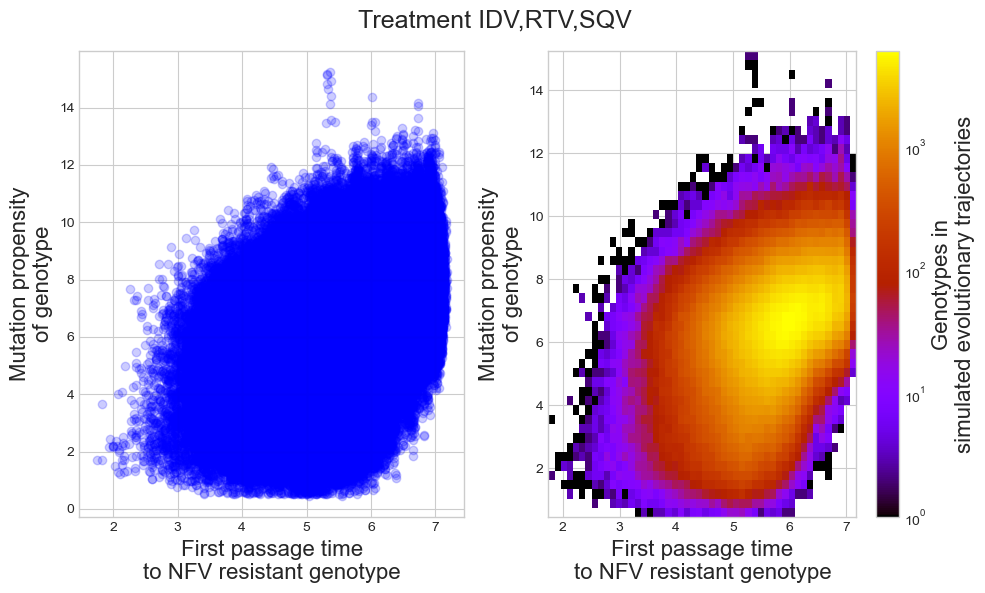

In [41]:
# PLOT Figure 3a to show scatter plot of log(-log prog to reach drug res) and mutation propensity


import matplotlib as mpl
import matplotlib.pylab as plt

fig, axs = plt.subplots(1, 2, figsize=(10,6))

axs[0].scatter(all_unique_log_log_prob, all_unique_fitness, alpha=0.2, color='blue')
axs[0].set_xlabel(f'First passage time\nto {example_drug_res} resistant genotype', fontsize=16)
axs[0].set_ylabel(f'Mutation propensity\nof genotype', fontsize=16)

# Store the return value from hist2d
im = axs[1].hist2d(all_unique_log_log_prob, all_unique_fitness, norm=mpl.colors.LogNorm(), cmap=mpl.cm.gnuplot, bins=50)

# Use fig.colorbar() and pass the mappable object
cbar = fig.colorbar(im[3], ax=axs[1])  # im[3] is the mappable object
cbar.set_label('Genotypes in\nsimulated evolutionary trajectories', fontsize=16)

axs[1].set_xlabel(f'First passage time\nto {example_drug_res} resistant genotype', fontsize=16)
axs[1].set_ylabel(f'Mutation propensity\nof genotype', fontsize=16)

plt.suptitle(f'Treatment {example_treatment}', fontsize=18)


plt.tight_layout()

plt.savefig(f'fig3a_revision.jpg', dpi=600, bbox_inches='tight')

plt.show()



Text(0.5, 1.0, 'Treatment IDV,RTV,SQV')

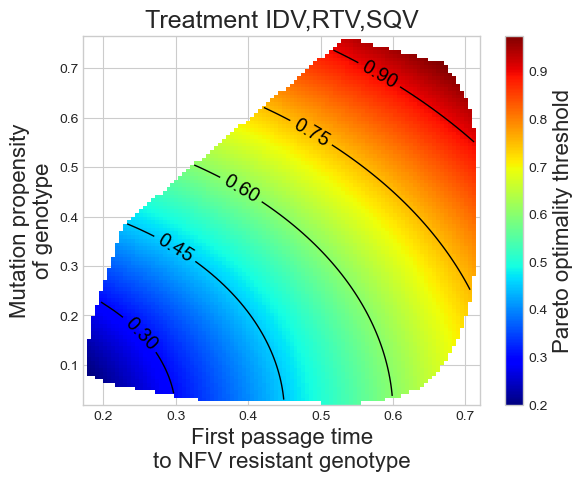

In [42]:
# PLOT Figure 3b to show introduce PHI

import matplotlib as mpl
import matplotlib.pylab as plt
import numpy as np
from scipy.interpolate import griddata

normalization_factor_prob_to_reach = 10
normalization_mutation_propensity = 20

scaled_prob_to_reach = all_unique_log_log_prob/normalization_factor_prob_to_reach
scaled_fitness = all_unique_fitness/normalization_mutation_propensity

phi_norm = np.sqrt(scaled_prob_to_reach**2 + scaled_fitness**2)

x = scaled_prob_to_reach
y = scaled_fitness
z = phi_norm

# Create regular grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolate z values onto grid
zi = griddata((x, y), z, (xi, yi), method='cubic')

# Plot
surface = plt.pcolormesh(xi, yi, zi, cmap='jet')
cbar = plt.colorbar()
cbar.set_label('Pareto optimality threshold', fontsize=16)

# Add contour lines
contours = plt.contour(xi, yi, zi, levels=5, colors='black', alpha=1, linewidths=1)
plt.clabel(contours, inline=True, fontsize=14)  # Add labels to contour lines


plt.xlabel(f'First passage time\nto {example_drug_res} resistant genotype', fontsize=16)
plt.ylabel(f'Mutation propensity\nof genotype', fontsize=16)

plt.title(f'Treatment {example_treatment}', fontsize=18)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.20it/s]


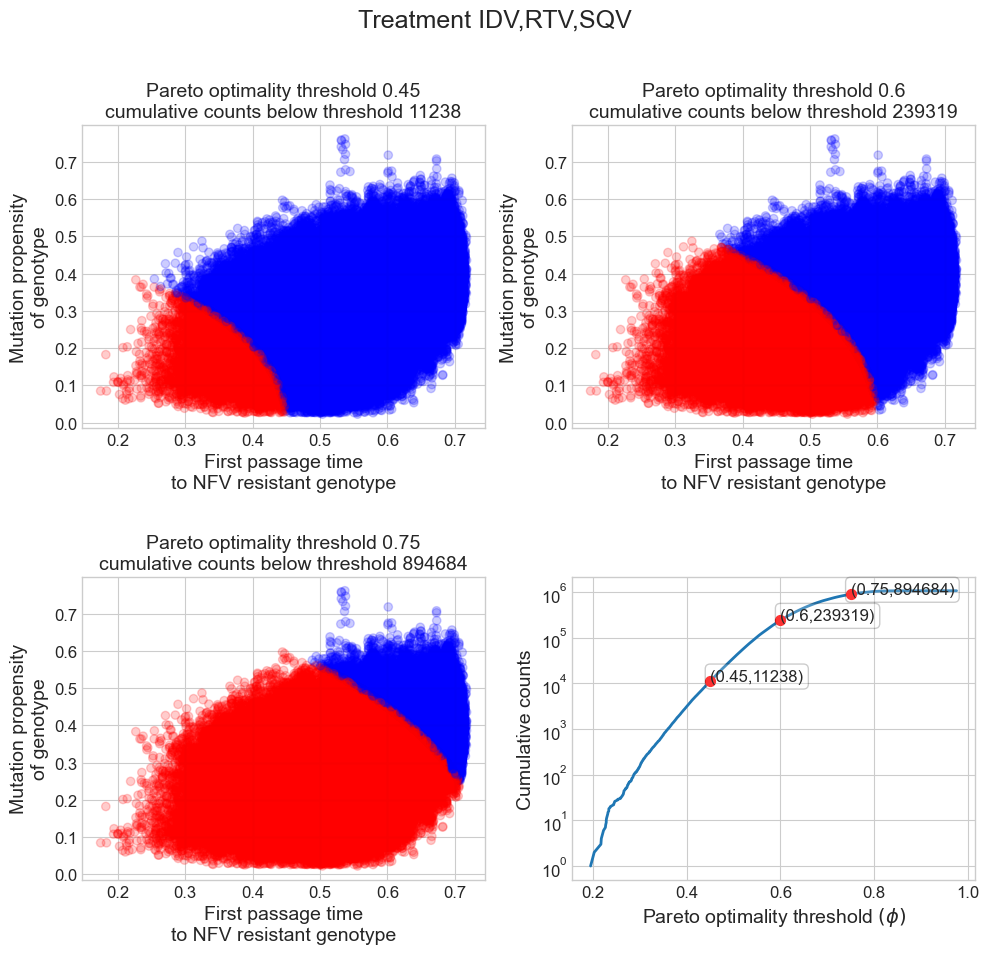

In [43]:
import matplotlib as mpl
import matplotlib.pylab as plt
from tqdm import tqdm
import numpy as np

n_rows = 2
n_cols = 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10,10))  # Slightly larger figure
plot_phi_thresh = [0.45, 0.6, 0.75]
x = scaled_prob_to_reach
y = scaled_fitness
z_val = phi_norm
row = 0
col = 0
marker_points = []

for thresh in tqdm(plot_phi_thresh):
    # Create color array based on threshold
    colors = ['red' if z_val < thresh else 'blue' for z_val in z]
    
    # Count points below threshold
    count_below_thresh = sum(1 for z_val in z if z_val < thresh)
    
    # Create scatter plot
    axs[row, col].scatter(x, y, c=colors, alpha=0.2)
    axs[row, col].set_xlabel(f'First passage time\nto {example_drug_res} resistant genotype', fontsize=14)
    axs[row, col].set_ylabel(f'Mutation propensity\nof genotype', fontsize=14)
    
    axs[row, col].set_title(f'Pareto optimality threshold {thresh}\ncumulative counts below threshold {count_below_thresh}', fontsize=14)
    
    # Increase tick label font sizes
    axs[row, col].tick_params(axis='both', which='major', labelsize=12)
    
    marker_points.append([thresh, count_below_thresh])
    col += 1
    if col == 2:
        row += 1
        col = 0

# Plot cumulative counts
values_sorted = np.sort(phi_norm)
cumulative_counts = np.arange(1, len(values_sorted) + 1)
axs[1,1].plot(values_sorted, cumulative_counts, linewidth=2)

for pt in marker_points:
    axs[1,1].scatter(pt[0], pt[1], color='red', zorder=1000, s=50)
    axs[1,1].text(pt[0], pt[1], f'({pt[0]},{pt[1]})', fontsize=12, zorder=1000, 
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.2))

axs[1,1].set_yscale('log')
axs[1,1].set_xlabel(r'Pareto optimality threshold $(\phi)$', fontsize=14)
axs[1,1].set_ylabel('Cumulative counts', fontsize=14)
axs[1,1].tick_params(axis='both', which='major', labelsize=12)

# Add main title with proper spacing
plt.suptitle(f'Treatment {example_treatment}', fontsize=18, y=0.95)

# Apply tight layout with padding for the suptitle and extra vertical spacing
plt.tight_layout(rect=[0, 0, 1, 0.93], h_pad=3.0)

plt.savefig(f'fig3b_revision.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [44]:
# COMMENTING BECAUSE ALREADY COMPUTED


from joblib import Parallel, delayed
import math

# Figure 3 to show scatter plot of log(-log prog to reach drug res) and mutation propensity

# Proposal: log(-log prog to reach drug res) -> 'Drug Susceptibility'


def single_fname(fname):
    
    treatment, beta, LOO = parse_fname(fname)

    if LOO is None:
        LOO = -1

    experiment_unique_fitness = dict()
    experiment_unique_log_log_prob = dict()


    dbfile = open(fname, 'rb')
    data = pickle.load(dbfile)
    dbfile.close()
    
    for walk in data:
    
        walk_mutations = walk['walk_mutations']
        walk_mutation_propensity = np.array(walk['walk_FEM_fitness'])
        walk_log_prob_step = np.array(walk['walk_log_prob_step'])

        walk_log_prob_to_reach = np.cumsum(walk_log_prob_step)
        walk_log_log_prob_to_reach = np.log(-walk_log_prob_to_reach)
    
        walk_seqs = []
    
        first_seq = PR_consensus.copy()
    
        this_seq = first_seq.copy()
    
        for mutate_bit_idx in walk_mutations:
            
            pos, AA = onehot_inv_map[treatment][mutate_bit_idx]
    
            this_seq[pos] = AA
    
            walk_seqs.append(this_seq.copy())
    
        walk_seqs = np.vstack(walk_seqs)

        # DRUG resistance

        for drug in walk['walk_drug_res']:

            if drug not in experiment_unique_fitness:
                experiment_unique_fitness[drug] = []
                experiment_unique_log_log_prob[drug] = []
                
            walk_drug_res = walk['walk_drug_res'][drug][0]
    
    
            drug_res_events = np.argwhere(walk_drug_res==1).flatten()
    
            drug_res_genotypes = walk_seqs[drug_res_events]
            drug_res_FEM_fitness = walk_mutation_propensity[drug_res_events]
            drug_res_log_log_prob_to_reach = walk_log_log_prob_to_reach[drug_res_events]
    
            drug_res_unique_genotypes, drug_res_unique_indices = np.unique(drug_res_genotypes, axis=0, return_index=True)
            
            drug_res_unique_FEM_fitness = drug_res_FEM_fitness[drug_res_unique_indices]
            drug_res_unique_log_log_prob_to_reach = drug_res_log_log_prob_to_reach[drug_res_unique_indices]

            experiment_unique_fitness[drug].append(drug_res_unique_FEM_fitness)
            experiment_unique_log_log_prob[drug].append(drug_res_unique_log_log_prob_to_reach)


    experiment_phi = dict()
    
    for drug in experiment_unique_fitness:

        this_experiment_unique_fitness = np.hstack(experiment_unique_fitness[drug])
        this_experiment_unique_log_log_prob = np.hstack(experiment_unique_log_log_prob[drug])
        
        scaled_fitness = this_experiment_unique_fitness/normalization_mutation_propensity
        scaled_prob_to_reach = this_experiment_unique_log_log_prob/normalization_factor_prob_to_reach

        phi_norm = np.sqrt(scaled_prob_to_reach**2 + scaled_fitness**2)

        hist, _ = np.histogram(phi_norm, bins=1000, range=(0, math.sqrt(2)))

        experiment_phi[drug] = hist


    return treatment, beta, LOO, experiment_phi


res = Parallel(n_jobs=24, verbose=4)\
        (delayed(single_fname)(fname) for fname in fnames)



[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done  50 tasks      | elapsed:   36.0s
[Parallel(n_jobs=24)]: Done 173 tasks      | elapsed:  1.7min
[Parallel(n_jobs=24)]: Done 344 tasks      | elapsed:  2.8min
[Parallel(n_jobs=24)]: Done 565 tasks      | elapsed:  3.7min
[Parallel(n_jobs=24)]: Done 834 tasks      | elapsed:  4.7min
[Parallel(n_jobs=24)]: Done 1153 tasks      | elapsed:  5.6min
[Parallel(n_jobs=24)]: Done 1520 tasks      | elapsed:  6.7min
[Parallel(n_jobs=24)]: Done 1937 tasks      | elapsed:  8.1min
[Parallel(n_jobs=24)]: Done 2402 tasks      | elapsed: 14.8min
[Parallel(n_jobs=24)]: Done 2917 tasks      | elapsed: 20.4min
[Parallel(n_jobs=24)]: Done 3480 tasks      | elapsed: 25.4min
[Parallel(n_jobs=24)]: Done 4093 tasks      | elapsed: 29.6min
[Parallel(n_jobs=24)]: Done 4754 tasks      | elapsed: 35.5min
[Parallel(n_jobs=24)]: Done 5465 tasks      | elapsed: 39.9min
[Parallel(n_jobs=24)]: Done 6224 tasks      | 

In [45]:
# # COMMENTING BECAUSE ALREADY COMPUTED

# IMPORTANT TO COMMENT IF ALREADY COMPUTED!

fname = 'consolidated_binned_phi_1000.p'
dbfile = open(fname, 'wb')
pickle.dump(res, dbfile)
dbfile.close()


fname = 'consolidated_binned_phi_1000.p'
dbfile = open(fname, 'rb')
res = pickle.load(dbfile)
dbfile.close()


In [46]:

all_experiment_phi = dict()


for rr in res:

    treatment, beta, LOO, experiment_phi = rr

    if treatment not in all_experiment_phi:
        all_experiment_phi[treatment] = dict()

    if LOO not in all_experiment_phi[treatment]:
        all_experiment_phi[treatment][LOO] = dict()

    for drug in experiment_phi:
        if drug not in all_experiment_phi[treatment][LOO]:
            all_experiment_phi[treatment][LOO][drug] = experiment_phi[drug]
        else:
            # Simply add counts in the bins across different beta
            all_experiment_phi[treatment][LOO][drug] += experiment_phi[drug]




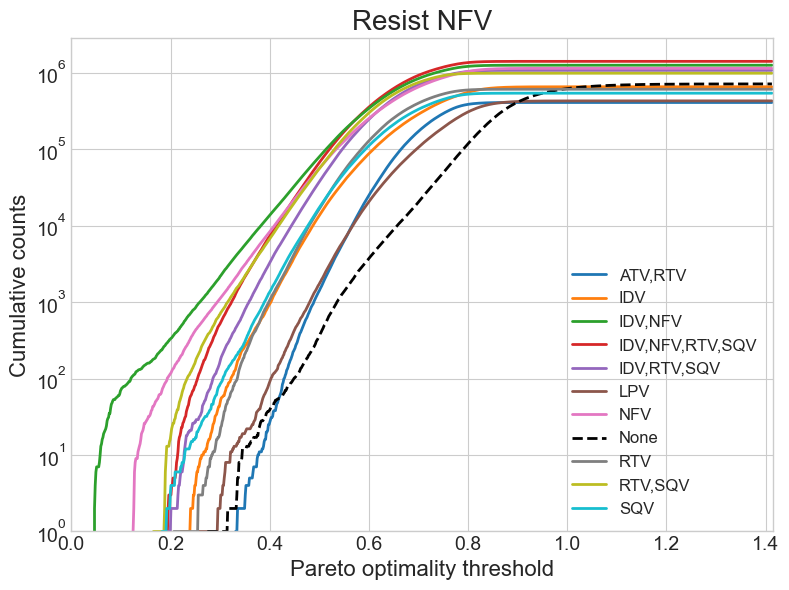

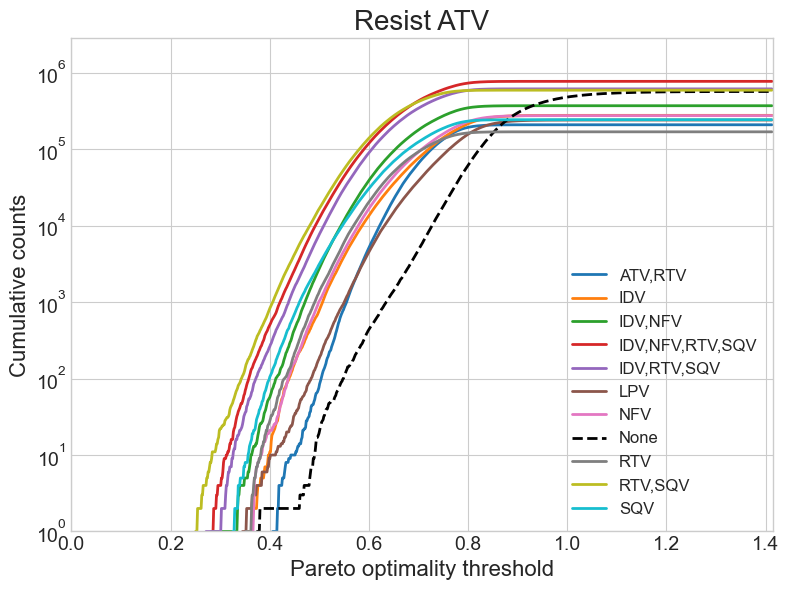

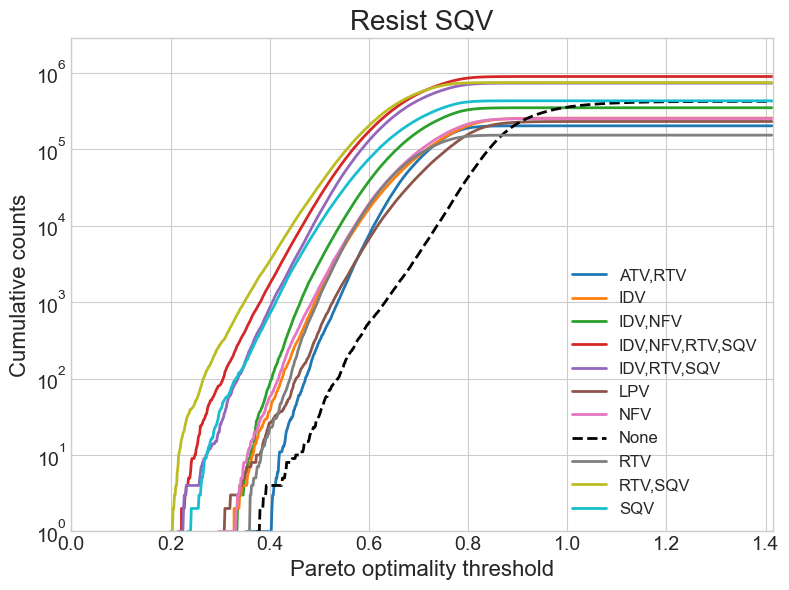

In [47]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Get all unique treatments first
all_treatments = set()
for treatment in all_experiment_phi:
    all_treatments.add(treatment)

# Define a consistent color mapping for ALL treatments
colors = ['black', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 
          'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
          'darkred', 'darkblue', 'darkgreen', 'darkorange', 'darkviolet',
          'goldenrod', 'indigo', 'crimson', 'forestgreen', 'navy']

# Create mapping ensuring 'None' gets black and is dashed
treatment_colors = {}
sorted_treatments = sorted(all_treatments)

# Assign 'None' first if it exists
if 'None' in sorted_treatments:
    treatment_colors['None'] = 'black'
    sorted_treatments.remove('None')

# Assign colors to remaining treatments
for i, treatment in enumerate(sorted_treatments):
    treatment_colors[treatment] = colors[(i + 1) % len(colors)]  # +1 to skip black

# Define consistent line styles
treatment_linestyles = {
    'None': '--',  # Dashed for None
    # All others get solid lines (default)
}

xx = np.linspace(0, math.sqrt(2), endpoint=False, num=1000)

# Pre-calculate all data to determine global axis limits
all_plot_data = {}
global_y_min = float('inf')
global_y_max = float('-inf')

do_drugs = ['NFV', 'ATV', 'SQV']

# First pass: collect all data and find global limits
# for drug in all_experiment_phi['None'][-1]:

for drug in do_drugs:
    all_plot_data[drug] = {}
    
    for treatment in all_experiment_phi:
        treatment_cumsum = np.cumsum(all_experiment_phi[treatment][-1][drug])
        treatment_final_val = treatment_cumsum[-1]
        
        # Skip if final cumulative value is less than 10
        if treatment_final_val < 10:
            continue
            
        all_plot_data[drug][treatment] = treatment_cumsum
        
        # Update global limits
        y_min, y_max = np.min(treatment_cumsum), np.max(treatment_cumsum)
        global_y_min = min(global_y_min, y_min)
        global_y_max = max(global_y_max, y_max)

# Add some padding to the limits (for log scale, use multiplicative padding)
global_y_min = max(1, global_y_min * 0.5)  # Don't go below 1 for log scale
global_y_max *= 2.0

# Second pass: create plots with consistent limits
# for drug in all_experiment_phi['None'][-1]:
for drug in do_drugs:
    plt.figure(figsize=(8, 6))
    
    # Use pre-calculated data for this drug
    treatment_data = all_plot_data[drug]
    
    if not treatment_data:  # Skip if no valid treatments for this drug
        print(f"No valid treatments for {drug}, skipping plot")
        plt.close()
        continue
    
    for treatment in treatment_data:
        color = treatment_colors[treatment]
        linestyle = treatment_linestyles.get(treatment, '-')  # Default to solid line
        
        plt.plot(xx, treatment_data[treatment], 
                label=treatment, 
                color=color,
                linestyle=linestyle,
                linewidth=2)
    
    plt.title(f'Resist {drug}', fontsize=20)
    plt.xlabel('Pareto optimality threshold', fontsize=16)
    plt.ylabel('Cumulative counts', fontsize=16)
    plt.yscale('log')

    
    # Increase tick label font sizes
    plt.tick_params(axis='x', which='major', labelsize=14)
    plt.tick_params(axis='y', which='major', labelsize=14)
    
    # Set consistent axis limits across all plots
    plt.xlim(0, math.sqrt(2))
    plt.ylim(global_y_min, global_y_max)
    
    # Sort legend entries for consistency
    handles, labels = plt.gca().get_legend_handles_labels()
    sorted_pairs = sorted(zip(labels, handles))
    sorted_labels, sorted_handles = zip(*sorted_pairs)
    
    plt.legend(sorted_handles, sorted_labels, fontsize=12)
    plt.tight_layout()

    plt.savefig(f'fig4a_drug{drug}_revision.jpg', dpi=600, bbox_inches='tight')
    
    plt.show()


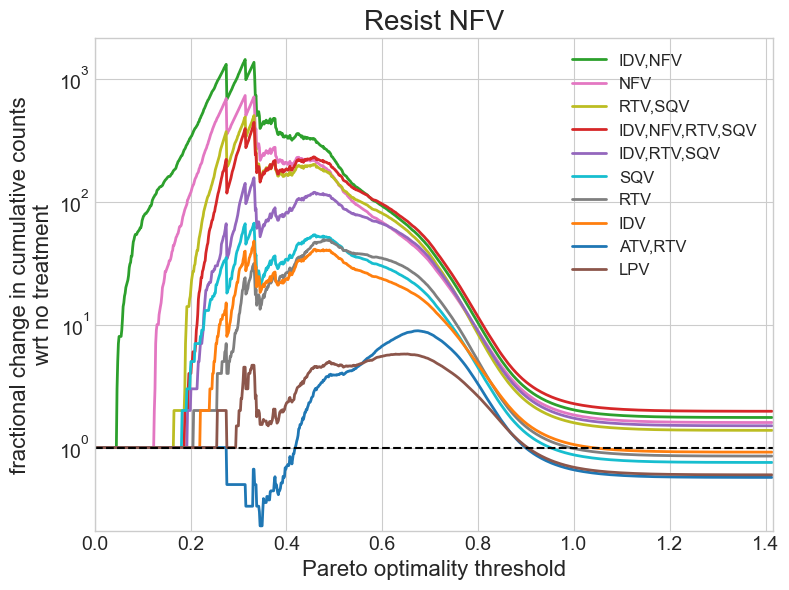

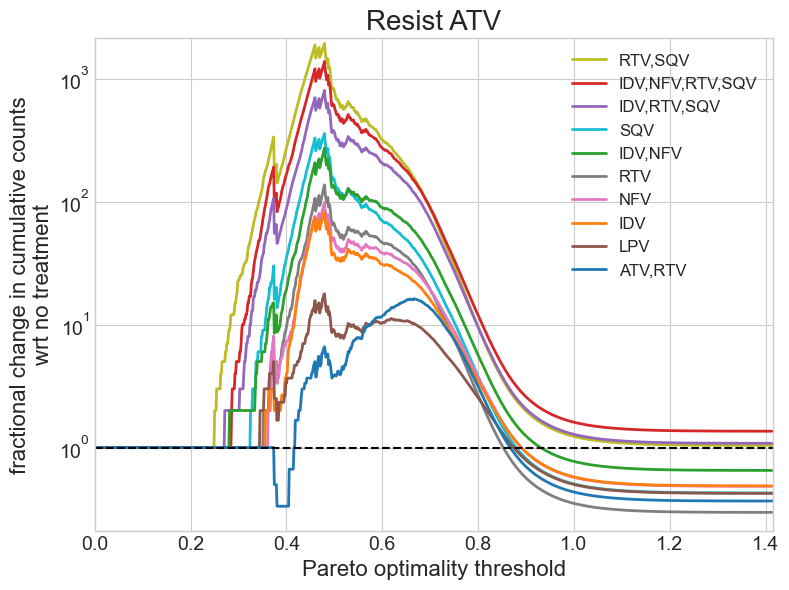

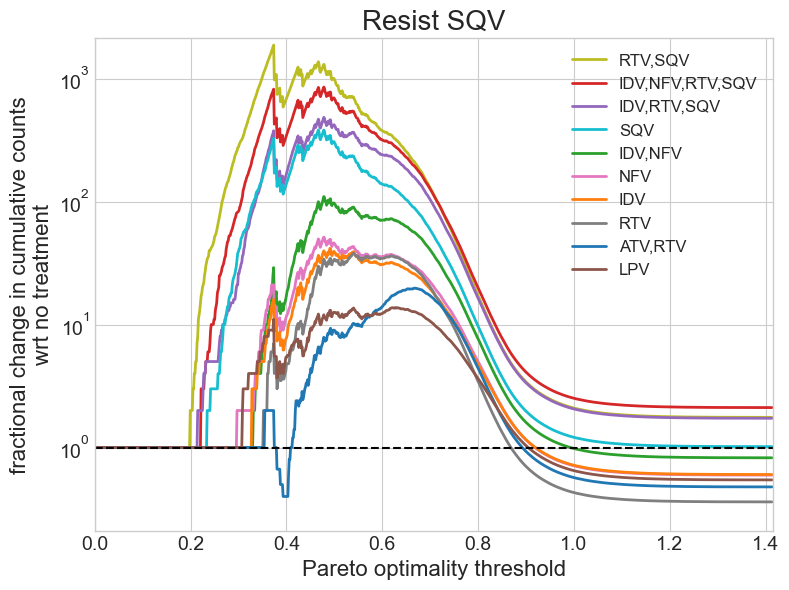

In [48]:
import math
import matplotlib.pyplot as plt
import numpy as np



xx = np.linspace(0, math.sqrt(2), endpoint=False, num=1000)

# Pre-calculate all data to determine global axis limits
all_plot_data = {}
global_y_min = float('inf')
global_y_max = float('-inf')

# First pass: collect all data and find global limits
for drug in do_drugs:
    all_plot_data[drug] = {}
    
    for treatment in all_experiment_phi:
        if treatment == 'None':
            continue
        
        # Calculate cumulative sums
        val1 = np.cumsum(all_experiment_phi[treatment][-1][drug])
        val2 = np.cumsum(all_experiment_phi['None'][-1][drug])
        
        # Check if both final values are less than 10
        if val1[-1] < 10 and val2[-1] < 10:
            continue
        
        # Use the more stable formula
        y_values = (1 + val1) / (1 + val2)
        all_plot_data[drug][treatment] = y_values
        
        # Update global limits
        y_min, y_max = np.min(y_values), np.max(y_values)
        global_y_min = min(global_y_min, y_min)
        global_y_max = max(global_y_max, y_max)

# Add some padding to the limits
y_padding = 0.1  # 10% padding
global_y_min *= (1 - y_padding)
global_y_max *= (1 + y_padding)

# Second pass: create plots with consistent limits
for drug in do_drugs:
    plt.figure(figsize=(8, 6))
    
    # Use pre-calculated data for this drug
    treatment_data = all_plot_data[drug]
    
    if not treatment_data:  # Skip if no valid treatments for this drug
        print(f"No valid treatments for {drug}, skipping plot")
        plt.close()
        continue
    
    # Calculate peak values for sorting
    peak_values = {treatment: np.max(y_values) for treatment, y_values in treatment_data.items()}
    
    # Sort treatments by peak value (descending - highest peaks first)
    treatments_sorted_by_peak = sorted(peak_values.keys(), 
                                     key=lambda t: peak_values[t], 
                                     reverse=True)
    
    # Plot in the sorted order
    for treatment in treatments_sorted_by_peak:
        plt.plot(xx, treatment_data[treatment], 
                label=treatment, 
                color=treatment_colors[treatment],
                linewidth=2)
    
    plt.title(f'Resist {drug}', fontsize=20)
    plt.ylabel('fractional change in cumulative counts\nwrt no treatment', fontsize=16)
    plt.xlabel('Pareto optimality threshold', fontsize=16)
    plt.axhline(y=1, ls='--', color='black')
    plt.yscale('log')

    # Increase tick label font sizes
    plt.tick_params(axis='x', which='major', labelsize=14)
    plt.tick_params(axis='y', which='major', labelsize=14)
    
    # Set consistent axis limits across all plots
    plt.xlim(0, math.sqrt(2))
    plt.ylim(global_y_min, global_y_max)
    
    # Legend will automatically be in the order we plotted (sorted by peak)
    plt.legend(fontsize=12)
    plt.tight_layout()

    plt.savefig(f'fig4b_drug{drug}_revision.jpg', dpi=600, bbox_inches='tight')
    plt.show()


/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [ 53 142 199]
  Selected: 63P -> -0.348
  Selected: 90M -> -0.234
  Selected: 30N -> -0.116
IDV,NFV,RTV,SQV::NFV - Position 63, AA P, Signed log area: -0.348
IDV,NFV,RTV,SQV::NFV - Position 90, AA M, Signed log area: -0.234
IDV,NFV,RTV,SQV::NFV - Position 30, AA N, Signed log area: -0.116


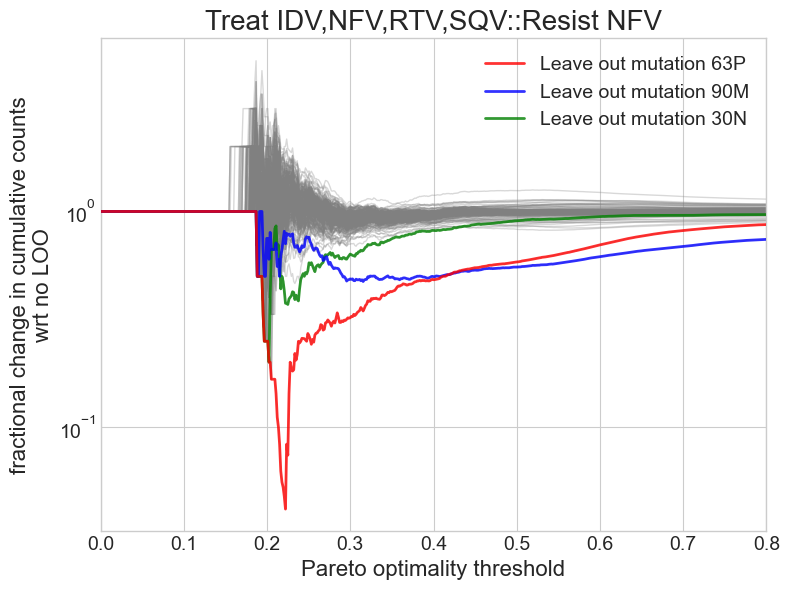

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [183  46 128]
  Selected: 30N -> -0.325
  Selected: 63P -> -0.174
  Selected: 88S -> -0.072
IDV,NFV::NFV - Position 30, AA N, Signed log area: -0.325
IDV,NFV::NFV - Position 63, AA P, Signed log area: -0.174
IDV,NFV::NFV - Position 88, AA S, Signed log area: -0.072


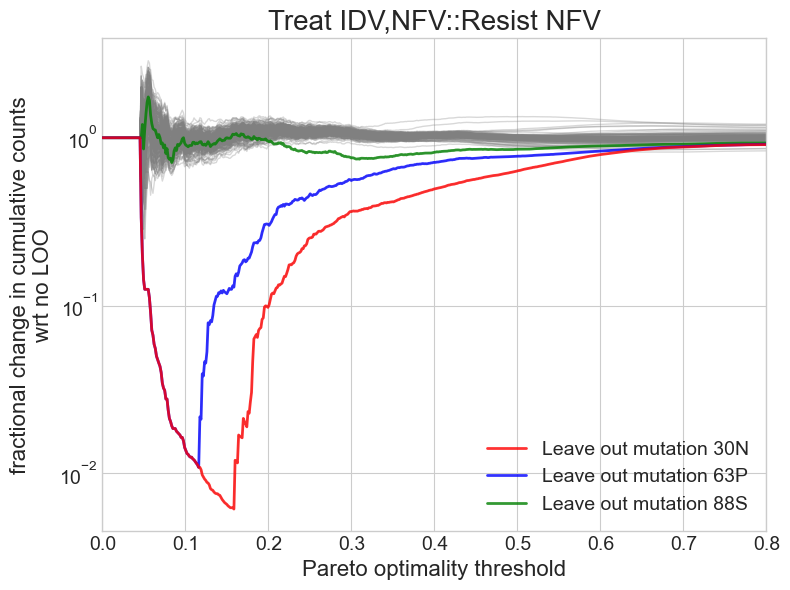

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [136  52  86]
  Selected: 90M -> -0.525
  Selected: 63P -> -0.378
  Selected: 71V -> -0.218
IDV,RTV,SQV::NFV - Position 90, AA M, Signed log area: -0.525
IDV,RTV,SQV::NFV - Position 63, AA P, Signed log area: -0.378
IDV,RTV,SQV::NFV - Position 71, AA V, Signed log area: -0.218


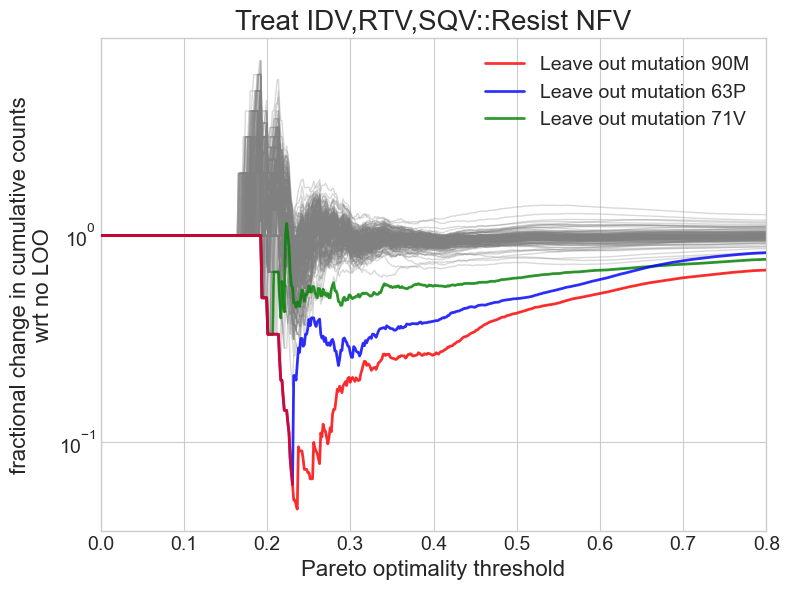

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [72 19  0]
  Selected: 84C -> -0.304
  Selected: 63P -> -0.104
  Selected: 10I -> -0.079
RTV,SQV::NFV - Position 84, AA C, Signed log area: -0.304
RTV,SQV::NFV - Position 63, AA P, Signed log area: -0.104
RTV,SQV::NFV - Position 10, AA I, Signed log area: -0.079


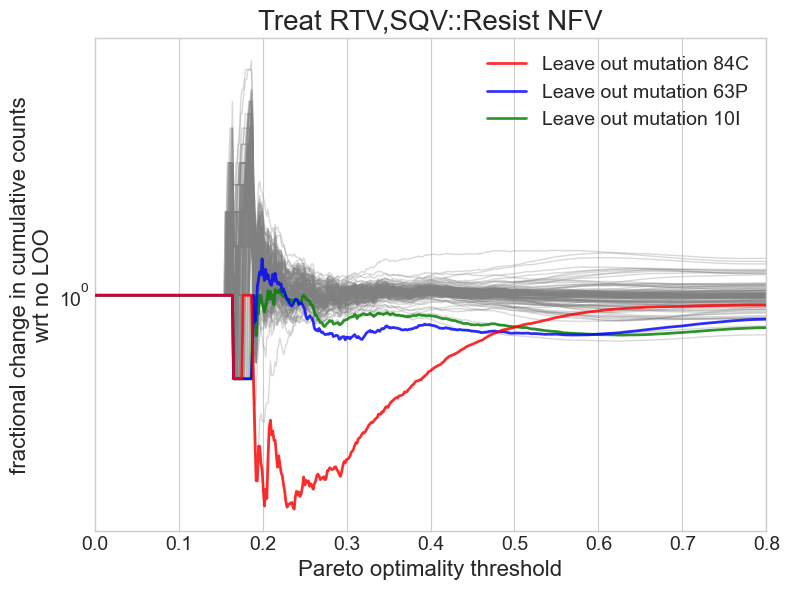

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [ 35 142  21]
  Selected: 10I -> -0.369
  Selected: 90M -> -0.309
  Selected: 48V -> -0.242
IDV,NFV,RTV,SQV::ATV - Position 10, AA I, Signed log area: -0.369
IDV,NFV,RTV,SQV::ATV - Position 90, AA M, Signed log area: -0.309
IDV,NFV,RTV,SQV::ATV - Position 48, AA V, Signed log area: -0.242


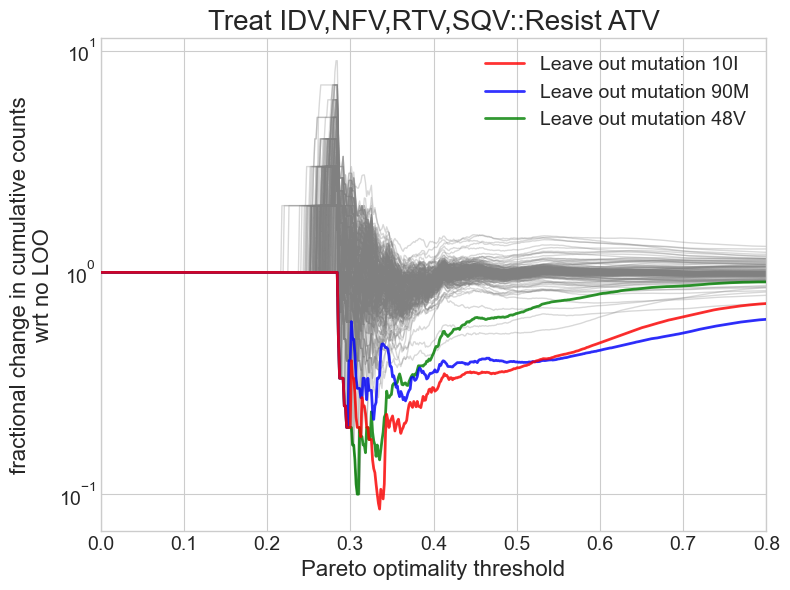

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [136  12 173]
  Selected: 90M -> -0.432
  Selected: 46I -> -0.209
  Selected: 20T -> -0.200
IDV,NFV::ATV - Position 90, AA M, Signed log area: -0.432
IDV,NFV::ATV - Position 46, AA I, Signed log area: -0.209
IDV,NFV::ATV - Position 20, AA T, Signed log area: -0.200


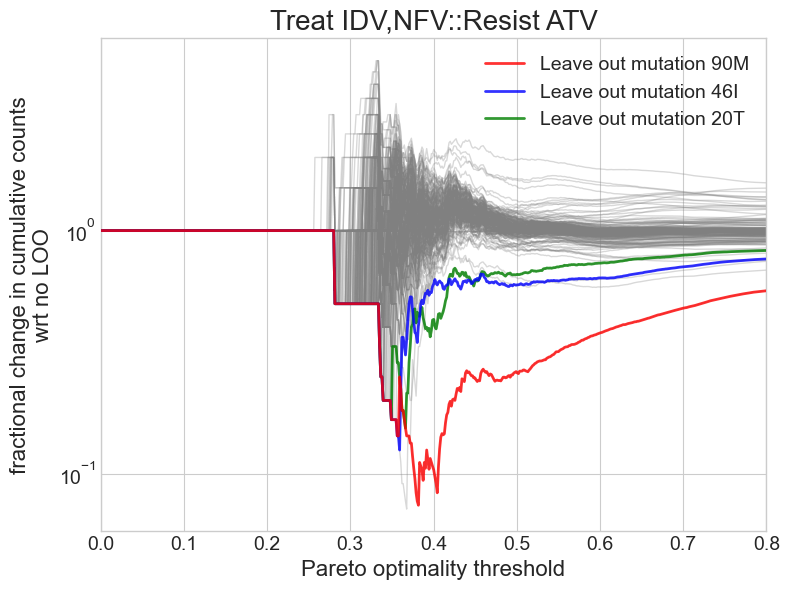

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [ 16 120 136]
  Selected: 10I -> -0.404
  Selected: 84V -> -0.280
  Selected: 90M -> -0.267
IDV,RTV,SQV::ATV - Position 10, AA I, Signed log area: -0.404
IDV,RTV,SQV::ATV - Position 84, AA V, Signed log area: -0.280
IDV,RTV,SQV::ATV - Position 90, AA M, Signed log area: -0.267


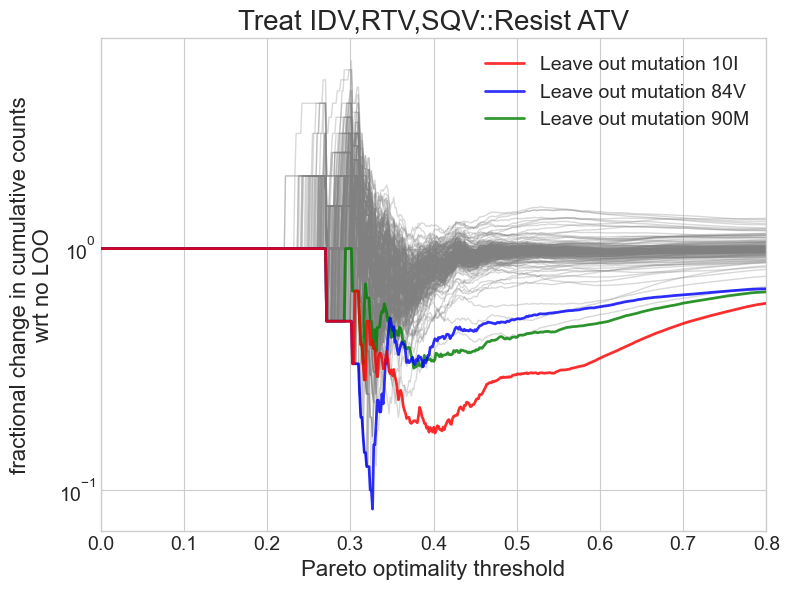

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [ 0 71 37]
  Selected: 10I -> -0.300
  Selected: 84A -> -0.234
  Selected: 71V -> -0.190
RTV,SQV::ATV - Position 10, AA I, Signed log area: -0.300
RTV,SQV::ATV - Position 84, AA A, Signed log area: -0.234
RTV,SQV::ATV - Position 71, AA V, Signed log area: -0.190


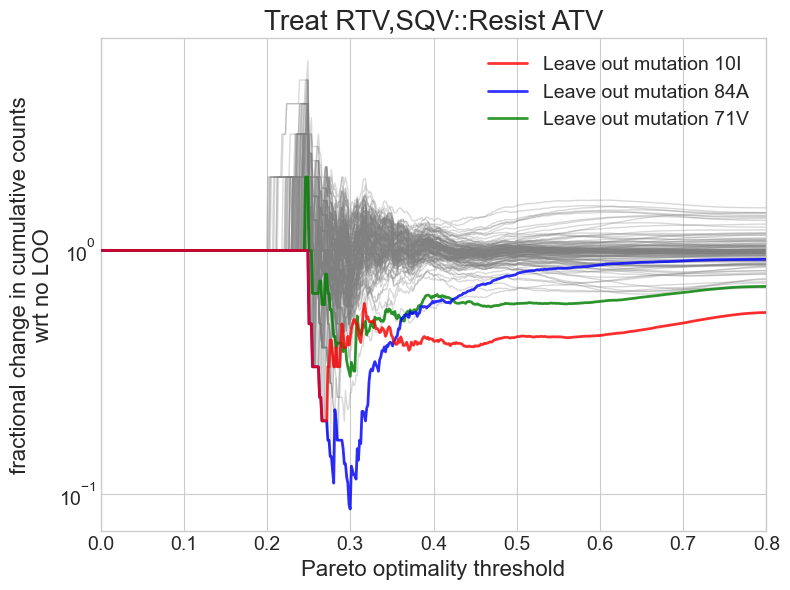

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [ 21 142  35]
  Selected: 48V -> -0.423
  Selected: 90M -> -0.259
  Selected: 10I -> -0.248
IDV,NFV,RTV,SQV::SQV - Position 48, AA V, Signed log area: -0.423
IDV,NFV,RTV,SQV::SQV - Position 90, AA M, Signed log area: -0.259
IDV,NFV,RTV,SQV::SQV - Position 10, AA I, Signed log area: -0.248


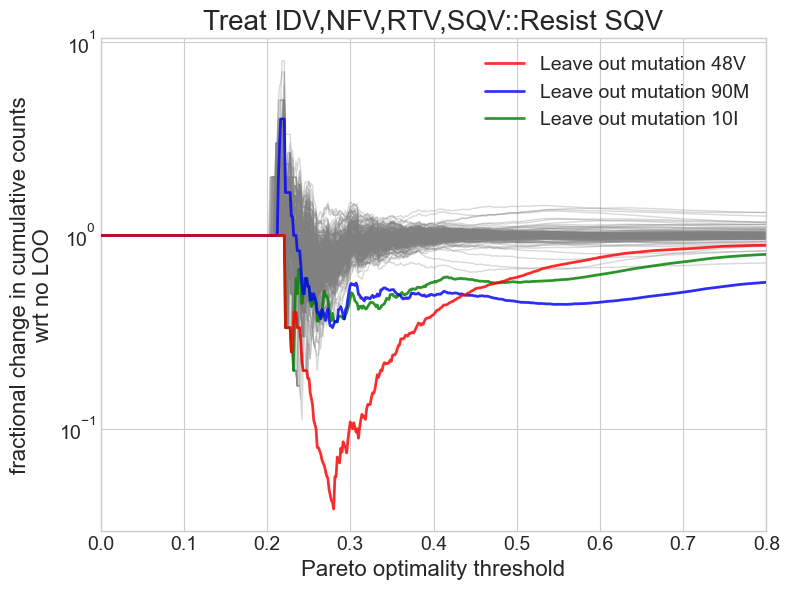

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [136  82  23]
  Selected: 90M -> -0.360
  Selected: 71V -> -0.109
  Selected: 54V -> -0.086
IDV,NFV::SQV - Position 90, AA M, Signed log area: -0.360
IDV,NFV::SQV - Position 71, AA V, Signed log area: -0.109
IDV,NFV::SQV - Position 54, AA V, Signed log area: -0.086


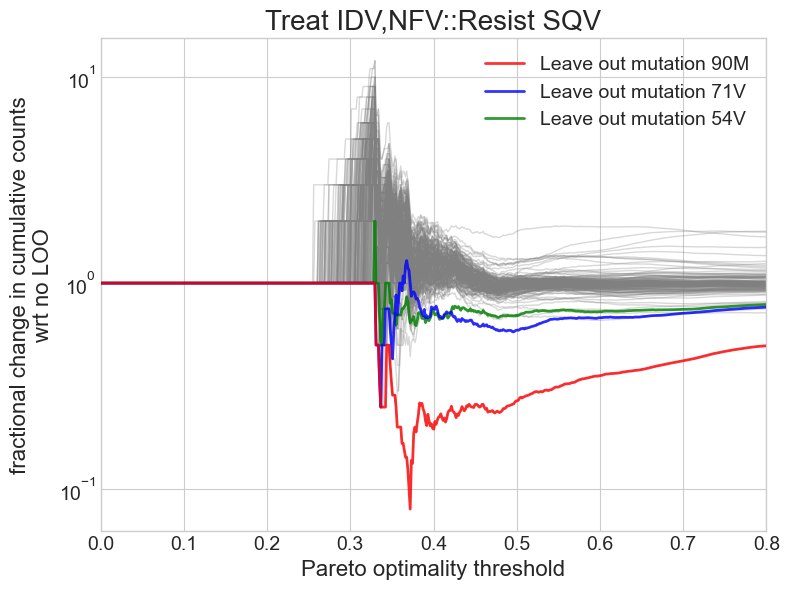

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [136 120  16]
  Selected: 90M -> -0.383
  Selected: 84V -> -0.356
  Selected: 10I -> -0.271
IDV,RTV,SQV::SQV - Position 90, AA M, Signed log area: -0.383
IDV,RTV,SQV::SQV - Position 84, AA V, Signed log area: -0.356
IDV,RTV,SQV::SQV - Position 10, AA I, Signed log area: -0.271


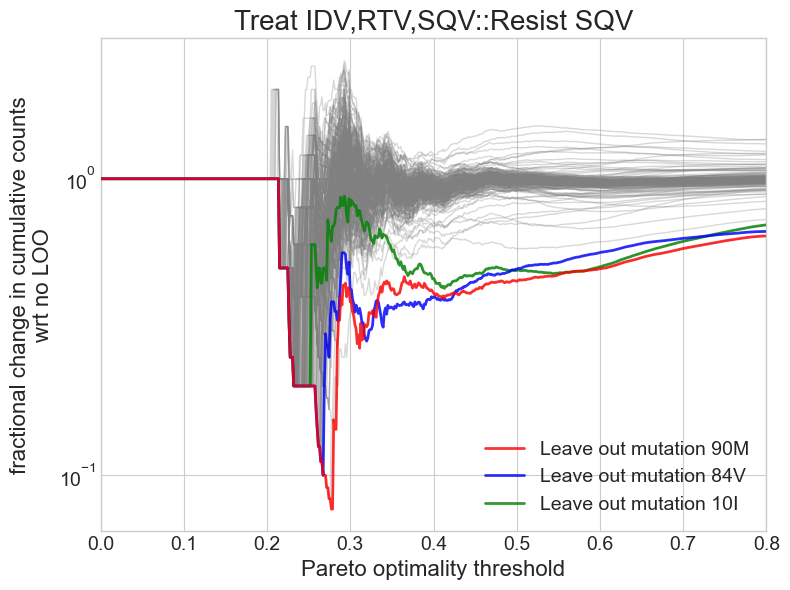

/tmp/ipykernel_3472013/1755097876.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  signed_log_area = np.trapz(log_deviation, xx_subset)



Selected top 3 indices: [ 0 71 72]
  Selected: 10I -> -0.169
  Selected: 84A -> -0.162
  Selected: 84C -> -0.145
RTV,SQV::SQV - Position 10, AA I, Signed log area: -0.169
RTV,SQV::SQV - Position 84, AA A, Signed log area: -0.162
RTV,SQV::SQV - Position 84, AA C, Signed log area: -0.145


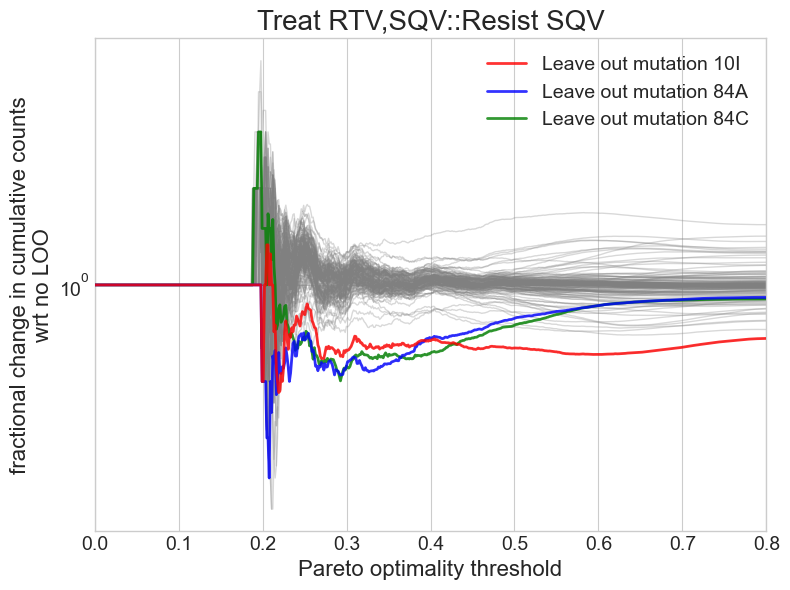

In [49]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Define treatments to process
do_treatments = ['IDV,NFV,RTV,SQV', 'IDV,RTV,SQV', 'RTV,SQV', 'IDV,NFV']

# Colors for bottom 3 LOOs
highlight_colors = ['red', 'blue', 'green']

xx = np.linspace(0, math.sqrt(2), endpoint=False, num=1000)

for drug in do_drugs:
    for treatment in all_experiment_phi:
        if treatment == 'None' or treatment not in do_treatments:
            continue
            
        LOO_min_change = []
        LOO_list = []
        valid_plots = []  # Store valid fractional change data
        valid_LOOs = []   # Store corresponding LOO indices
        
        for LOO in all_experiment_phi[treatment]:
            if LOO == -1:
                continue
                
            # Calculate cumulative sums
            val1 = np.cumsum(all_experiment_phi[treatment][LOO][drug])
            val2 = np.cumsum(all_experiment_phi[treatment][-1][drug])
            
            # Check if both final values are less than 10
            if val1[-1] < 10 and val2[-1] < 10:
                print(f"Skipping LOO {LOO} for {treatment}::{drug}: val1_max={val1[-1]:.1f}, val2_max={val2[-1]:.1f}")
                continue
            
            # Use the more stable formula
            frac_change = (1 + val1) / (1 + val2)
            
            # Calculate signed log-scale area relative to baseline (1.0) 
            # but only for x values between 0.2 and 0.6 to avoid noisy spike regions
            mask = (xx >= 0.2) & (xx <= 0.6)
            xx_subset = xx[mask]
            frac_change_subset = frac_change[mask]
            
            # Calculate signed log area only in the stable region
            log_deviation = np.log(frac_change_subset)  # Positive when >1, negative when <1
            signed_log_area = np.trapz(log_deviation, xx_subset)
            
            # Store negative so that largest negative impact (most reduction) sorts first
            LOO_min_change.append(-signed_log_area)
            LOO_list.append(LOO)
            valid_plots.append(frac_change)
            valid_LOOs.append(LOO)
        
        # Skip this treatment-drug combination if no valid LOO data
        if not valid_plots:
            print(f"No valid LOO data for {treatment}::{drug}, skipping")
            continue
        
        # # Debug: Print all LOO signed log areas in stable region [0.2, 0.6]
        # LOO_min_change = np.array(LOO_min_change)
        # print(f"\nDEBUG - All signed log areas (x∈[0.2,0.6]) for {treatment}::{drug}:")
        # for i, (loo_idx, area) in enumerate(zip(LOO_list, LOO_min_change)):
        #     pos, AA = onehot_inv_map[treatment][loo_idx]
        #     print(f"  {i}: {pos+1}{AA} -> {-area:.3f}")
        
        # Show the selected top 3 for comparison
        sorted_indices = np.argsort(LOO_min_change)[::-1]
        print(f"\nSelected top 3 indices: {sorted_indices[:3]}")
        for idx in sorted_indices[:3]:
            loo_idx = LOO_list[idx]
            pos, AA = onehot_inv_map[treatment][loo_idx]
            print(f"  Selected: {pos+1}{AA} -> {-LOO_min_change[idx]:.3f}")
            
        plt.figure(figsize=(8, 6))  # Wider figure to accommodate legend
        
        # Find the bottom 3 LOOs by most negative signed log area in stable region [0.2, 0.6]
        LOO_min_change = np.array(LOO_min_change)
        LOO_list = np.array(LOO_list)
        
        # Get indices sorted by most negative signed log area (we stored -signed_log_area, so most negative becomes most positive)
        sorted_indices = np.argsort(LOO_min_change)[::-1]  # Sort descending - largest first
        bot_n_indices = sorted_indices[:3] if len(sorted_indices) >= 3 else sorted_indices
        
        # Plot all valid fractional changes
        legend_info = []  # Store (area_value, label, color, line_data) for proper sorting
        
        # First plot all curves in gray
        for i, frac_change in enumerate(valid_plots):
            plt.plot(xx, frac_change, color='gray', alpha=0.3, linewidth=1, zorder=1)
        
        # Then highlight the top 3 with colors and higher zorder
        for rank, original_idx in enumerate(bot_n_indices):
            frac_change = valid_plots[original_idx]
            current_LOO = valid_LOOs[original_idx]
            
            pos, AA = onehot_inv_map[treatment][current_LOO]
            
            # Higher zorder for larger impact
            zorder_val = 1000 - rank * 100
            
            line = plt.plot(xx, frac_change, 
                           color=highlight_colors[rank], 
                           alpha=0.8, 
                           linewidth=2,
                           zorder=zorder_val)[0]
            
            # Store info for legend sorting - use the actual signed log area (not the negated version)
            actual_signed_log_area = -LOO_min_change[original_idx]  # Convert back to actual signed log area
            legend_info.append((actual_signed_log_area, f'Leave out mutation {pos+1}{AA}', line))

            print(f"{treatment}::{drug} - Position {pos+1}, AA {AA}, Signed log area: {actual_signed_log_area:.3f}")
            
        plt.title(f'Treat {treatment}::Resist {drug}', fontsize=20)
        plt.xlabel('Pareto optimality threshold', fontsize=16)
        plt.ylabel('fractional change in cumulative counts\nwrt no LOO', fontsize=16)
        plt.yscale('log')
        
        # Restrict x-axis to [0,0.8]
        plt.xlim(0, 0.8)
        
        # Increase tick label font sizes for consistency
        plt.tick_params(axis='x', which='major', labelsize=14)
        plt.tick_params(axis='y', which='major', labelsize=14)
        
        # Sort legend by minimum value (lowest first) and create legend
        legend_info.sort(key=lambda x: x[0])  # Sort by min_value
        handles = [info[2] for info in legend_info]
        labels = [info[1] for info in legend_info]
        plt.legend(handles, labels, fontsize=14, loc='best')
        
        plt.tight_layout()

        plt.savefig(f'fig5_treatment{treatment}_drug{drug}_revision.jpg', dpi=600, bbox_inches='tight')
        
        plt.show()